Generating synthetic data...

Original Data Head (First 5 rows):
    Height_cm   Weight_kg  Speed_mph    Jump_cm
0  196.169938   84.294079  26.437755  59.440579
1  165.549923   70.959341  27.038729  55.383635
2  202.017128   84.859052  32.586081  70.524217
3  235.084234  104.237707  32.005047  73.830601
4  168.871806   72.443195  30.248267  63.664104


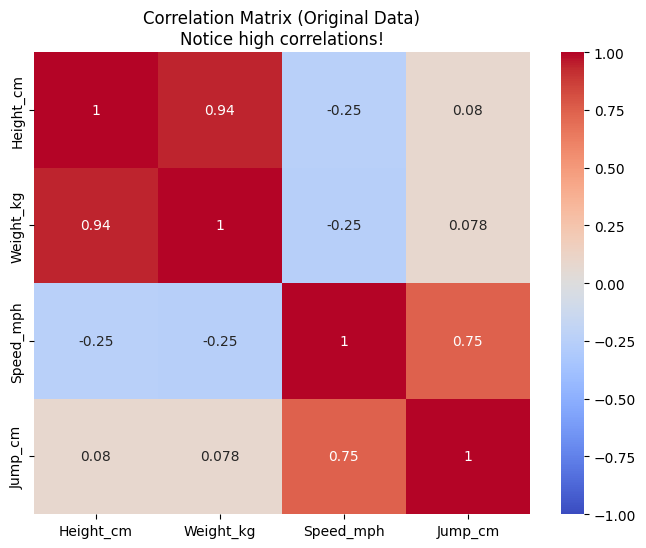


Standardizing data...
Applying PCA...

--- PCA Results Analysis ---
Principal Component 1: Explains 52.05% of the variance.
Principal Component 2: Explains 41.61% of the variance.
Principal Component 3: Explains 4.80% of the variance.
Principal Component 4: Explains 1.54% of the variance.

Cumulative Variance explained by first 2 components: 93.66%
This means we can reduce data from 4D to 2D and still keep most of the information!


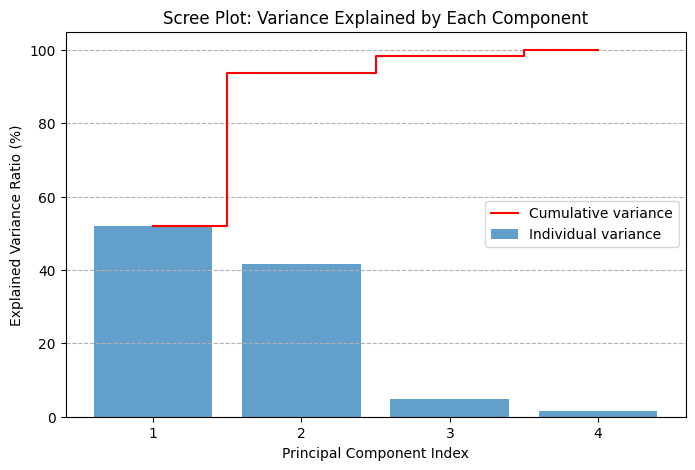

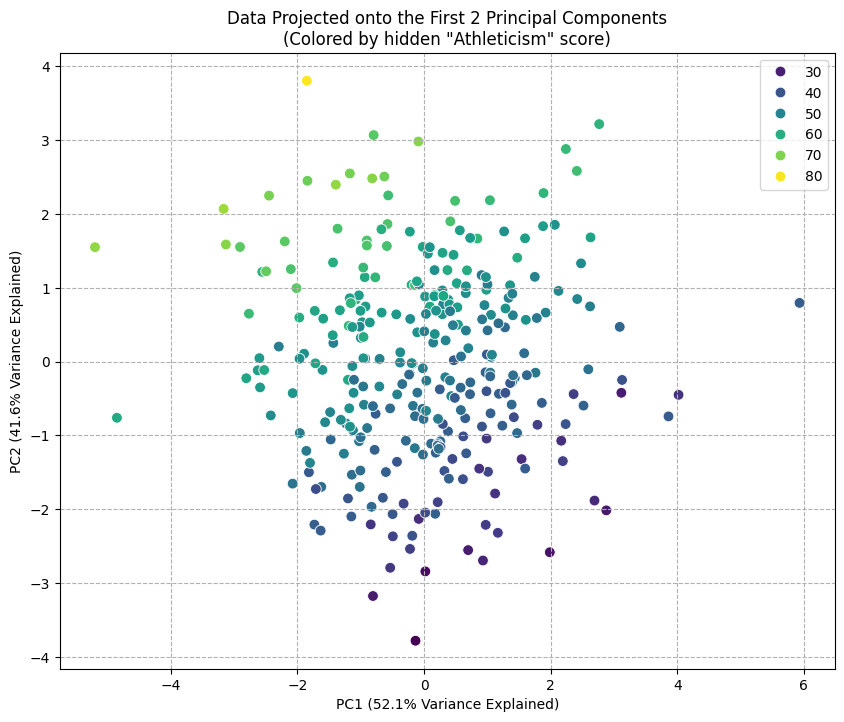


Interpretation of the final plot:
The X-axis (PC1) likely captures overall 'Size' (Height/Weight correlation).
The Y-axis (PC2) likely captures 'Athleticism' (Speed/Jump correlation independent of size).
Notice how the colors (our hidden athleticism score) form a gradient along the Y-axis.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Set seed for reproducibility
np.random.seed(42)

# =========================================
# Step 1: Generate Synthetic Correlated Data
# =========================================
print("Generating synthetic data...")
n_samples = 300

# We create hidden "latent" variables that drive the observable features.
# Imagine 'Size' and 'Athleticism' are the real underlying drivers.
true_size = np.random.normal(loc=50, scale=10, size=n_samples)
true_athleticism = np.random.normal(loc=50, scale=10, size=n_samples)

# Generate observable features based on these latent variables (with some noise added)
# Height and Weight are strongly tied to 'Size'
height_cm = (true_size * 3.5) + np.random.normal(0, 5, n_samples)
weight_kg = (true_size * 1.5) + np.random.normal(0, 5, n_samples)

# Speed and Jump are strongly tied to 'Athleticism', but bigger size slightly hinders speed
sprint_speed_mph = (true_athleticism * 0.4) - (true_size * 0.1) + np.random.normal(15, 2, n_samples)
jump_height_cm = (true_athleticism * 1.2) + (true_size * 0.1) + np.random.normal(0, 5, n_samples)

# Create a DataFrame
data = pd.DataFrame({
    'Height_cm': height_cm,
    'Weight_kg': weight_kg,
    'Speed_mph': sprint_speed_mph,
    'Jump_cm': jump_height_cm
})

# Display first few rows of the original data
print("\nOriginal Data Head (First 5 rows):")
print(data.head())

# --- Visualization 1: Correlation Heatmap BEFORE PCA ---
# This shows that the features are highly correlated (redundant information).
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix (Original Data)\nNotice high correlations!")
plt.show()


# =========================================
# Step 2: Standardization (CRITICAL STEP)
# =========================================
# PCA is sensitive to the scale of the data. We must standardize features
# to have a mean of 0 and a standard deviation of 1.
print("\nStandardizing data...")
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

# Convert back to pandas DF for easier handling (optional)
scaled_df = pd.DataFrame(scaled_data, columns=data.columns)


# =========================================
# Step 3: Apply PCA
# =========================================
# We have 4 initial features. Let's calculate all 4 PCs initially to see the variance.
print("Applying PCA...")
pca = PCA(n_components=4)
pca_data = pca.fit_transform(scaled_df)

# Create a dataframe for the PCA results
pca_columns = ['PC1', 'PC2', 'PC3', 'PC4']
pca_df = pd.DataFrame(data=pca_data, columns=pca_columns)


# =========================================
# Step 4: Analyze Explained Variance
# =========================================
# How much of the original information is captured by each new component?
var_ratios = pca.explained_variance_ratio_
cumulative_var = np.cumsum(var_ratios)

print("\n--- PCA Results Analysis ---")
for i, ratio in enumerate(var_ratios):
    print(f"Principal Component {i+1}: Explains {ratio*100:.2f}% of the variance.")

print(f"\nCumulative Variance explained by first 2 components: {cumulative_var[1]*100:.2f}%")
print("This means we can reduce data from 4D to 2D and still keep most of the information!")


# =========================================
# Step 5: Visualization of PCA Results
# =========================================

# --- Visualization 2: Scree Plot ---
# A bar plot showing how much variance each PC explains.
plt.figure(figsize=(8, 5))
plt.bar(range(1, 5), var_ratios * 100, alpha=0.7, align='center', label='Individual variance')
plt.step(range(1, 5), cumulative_var * 100, where='mid', color='red', label='Cumulative variance')
plt.ylabel('Explained Variance Ratio (%)')
plt.xlabel('Principal Component Index')
plt.title('Scree Plot: Variance Explained by Each Component')
plt.xticks([1, 2, 3, 4])
plt.legend(loc='best')
plt.grid(axis='y', linestyle='--')
plt.show()

# --- Visualization 3: 2D Projection (PC1 vs PC2) ---
# We project the 4D data onto the 2D plane defined by the first two PCs.
plt.figure(figsize=(10, 8))
# We will color the points by the hidden 'true_athleticism' score we created earlier
# to see if PCA successfully isolated that pattern.
sns.scatterplot(x='PC1', y='PC2', data=pca_df, hue=true_athleticism, palette='viridis', s=60)

plt.title('Data Projected onto the First 2 Principal Components\n(Colored by hidden "Athleticism" score)')
# Add the explained variance to the axis labels
plt.xlabel(f'PC1 ({var_ratios[0]*100:.1f}% Variance Explained)')
plt.ylabel(f'PC2 ({var_ratios[1]*100:.1f}% Variance Explained)')
plt.grid(True, linestyle='--')
plt.show()

print("\nInterpretation of the final plot:")
print("The X-axis (PC1) likely captures overall 'Size' (Height/Weight correlation).")
print("The Y-axis (PC2) likely captures 'Athleticism' (Speed/Jump correlation independent of size).")
print("Notice how the colors (our hidden athleticism score) form a gradient along the Y-axis.")